# 03 · Preparación de los datos (CRISP-DM — Fase 3)

Pipeline reproducible (todo vive en `src/data_prep.py`):

1. **Limpieza** del catálogo sísmico → fecha, hora, magnitud, profundidad, lat/lon.
2. **Unión espacial** (`geopandas.sjoin`) de cada sismo con su cantón;
   los sismos frente a la costa (subducción) se asignan al cantón más cercano
   en un radio de 150 km.
3. **Agregación por cantón**: n.º de sismos, magnitud máxima, profundidad media,
   energía total liberada (Gutenberg-Richter).
4. **Cruce con población** del Censo 2022 (INEC) y cálculo de densidad.

In [1]:
# --- Configuración común ---
import os
import sys
import pathlib

In [2]:
RAIZ = pathlib.Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))

In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
FIG = pathlib.Path("reports/figures")

In [5]:
from src import data_prep

In [6]:
# --- Paso 1: catálogo limpio ---
catalogo = data_prep.cargar_catalogo()
print(f"Catálogo limpio: {len(catalogo)} sismos, {catalogo['fecha_hora'].min()} → {catalogo['fecha_hora'].max()}")
catalogo.head(3)

Catálogo limpio: 2589 sismos, 1983-02-13 14:01:36.340000+00:00 → 2026-08-11 08:00:34.362000+00:00


,fecha_hora,fecha,hora,anio,mag,depth,latitude,longitude,magType,place,energia_j,id
0,1983-02-13 14:01:36.340000+00:00,1983-02-13,14:01:36,1983,4.4,33.0,-4.965,-80.327,mb,"4 km SSE of Tambo Grande, Peru",2.511886e+11,usp0001t0r
1,1983-02-18 08:55:46.910000+00:00,1983-02-18,08:55:46,1983,5.1,105.1,-3.113,-79.053,mb,"24 km SSW of Cuenca, Ecuador",2.818383e+12,usp0001t4y
2,1983-02-27 01:20:26.360000+00:00,1983-02-27,01:20:26,1983,4.2,126.6,-4.005,-76.404,mb,"58 km S of Alianza Cristiana, Peru",1.258925e+11,usp0001tbv


In [7]:
# --- Paso 2a: cantones (IGM/CONALI vía geoBoundaries) ---
cantones = data_prep.cargar_cantones()
print(f"Cantones cargados: {len(cantones)}")
cantones.head(3)

Cantones cargados: 224


,canton,geometry,canton_norm
0,24 de Mayo,"POLYGON ((-80.30045 -1.30952, -80.30705 -1.308...",24 DE MAYO
1,Aguarico,"POLYGON ((-75.26292 -0.65507, -75.2603 -0.6502...",AGUARICO
2,Alausi,"POLYGON ((-78.89515 -2.10487, -78.90007 -2.106...",ALAUSI


In [8]:
# --- Paso 2b: unión espacial sismo → cantón ---
sismos = data_prep.sismos_con_canton(catalogo, cantones)
dentro = (sismos["dist_km"] == 0).sum()
cerca = sismos["canton"].notna().sum() - dentro
print(f"Sismos dentro de un polígono cantonal: {dentro}")
print(f"Sismos costa afuera asignados al cantón más cercano (≤150 km): {cerca}")
print(f"Sin asignación (lejanos a cualquier cantón): {sismos['canton'].isna().sum()}")
sismos[["fecha", "hora", "mag", "depth", "latitude", "longitude", "canton", "dist_km"]].head(5)

Sismos dentro de un polígono cantonal: 1142
Sismos costa afuera asignados al cantón más cercano (≤150 km): 988
Sin asignación (lejanos a cualquier cantón): 459


,fecha,hora,mag,depth,latitude,longitude,canton,dist_km
0,1983-02-13,14:01:36,4.4,33.0,-4.965,-80.327,Zapotillo,59809.083173
1,1983-02-18,08:55:46,5.1,105.1,-3.113,-79.053,Cuenca,0.000000
2,1983-02-27,01:20:26,4.2,126.6,-4.005,-76.404,NaN,NaN
3,1983-03-15,17:15:36,4.8,125.4,0.587,-78.209,Ibarra,0.000000
4,1983-03-20,23:45:39,4.6,33.0,1.550,-79.626,Rioverde,61864.353122


La asignación por proximidad evita el sesgo clásico de los análisis cantonales:
sin ella, los cantones costeros "no sentirían" los grandes sismos de la interfaz
de subducción que ocurren decenas de km mar adentro.

In [9]:
# --- Paso 3: agregación por cantón ---
resumen = data_prep.agregar_por_canton(sismos)
resumen.sort_values("n_sismos", ascending=False).head(8)

,canton_norm,n_sismos,mag_max,prof_media_km,energia_total_j,primer_sismo,ultimo_sismo,n_sismos_someros,energia_somera_j,mag_max_somera
94,PASTAZA,248,7.5,152.995222,1.173043e+16,1983-04-27 21:06:00.880000+00:00,2026-08-02 17:09:44.170000+00:00,22.0,5.718346e+13,5.9
155,ZAPOTILLO,218,6.3,44.782665,6.547834e+14,1983-02-13 14:01:36.340000+00:00,2026-04-14 22:21:25.595000+00:00,194.0,6.450462e+14,6.3
146,TAISHA,113,6.7,79.601823,8.403826e+14,1983-11-25 22:56:25.880000+00:00,2026-05-23 08:44:52.458000+00:00,51.0,2.993762e+13,5.2
124,SAN LORENZO,71,6.2,25.975606,2.535741e+14,1984-07-30 02:47:20.800000+00:00,2025-08-25 18:10:57.293000+00:00,69.0,2.531970e+14,6.2
79,MUISNE,62,7.8,21.694887,3.309955e+16,1983-11-22 14:21:03.080000+00:00,2026-06-16 14:56:02.790000+00:00,61.0,3.309930e+16,7.8
76,MONTECRISTI,62,6.2,25.650629,3.242713e+14,1983-07-21 06:46:02.870000+00:00,2025-06-14 03:31:36.618000+00:00,62.0,3.242713e+14,6.2
24,CHINCHIPE,60,5.4,57.995967,4.948419e+13,1983-04-04 02:01:10.420000+00:00,2026-04-29 06:12:14.369000+00:00,40.0,4.317640e+13,5.4
128,SAN VICENTE,57,7.2,18.715877,4.344147e+15,1985-04-21 17:39:49.500000+00:00,2025-10-07 01:27:59.527000+00:00,57.0,4.344147e+15,7.2


In [10]:
# --- Paso 4: población del Censo 2022 y dataset cantonal final ---
poblacion = data_prep.cargar_poblacion()
print(f"Cantones con población censada: {len(poblacion)}")
poblacion.head(3)

Cantones con población censada: 219


,provincia,canton,poblacion_2022,canton_norm
0,Azuay,Cuenca,596101.0,CUENCA
1,Azuay,Girón,12182.0,GIRON
2,Azuay,Gualaceo,43188.0,GUALACEO


In [11]:
# --- Ejecutamos el pipeline completo (escribe data/processed/) ---
data_prep.ejecutar_pipeline()

[ok] Catálogo limpio: 2589 sismos (1983-2026)
[ok] Sismos asignados a cantón: 2130
[ok] Cantones con población censada: 221/224
[ok] Archivos generados en data/processed/


In [12]:
# --- Dataset final: verificación ---
base = gpd.read_file("data/processed/cantones_riesgo.geojson")
base[["canton", "provincia", "poblacion_2022", "area_km2", "densidad_hab_km2",
      "n_sismos", "mag_max", "prof_media_km", "energia_total_j"]].head(5)

,canton,provincia,poblacion_2022,area_km2,densidad_hab_km2,n_sismos,mag_max,prof_media_km,energia_total_j
0,24 de Mayo,Manabí,31473.0,529.634613,59.423986,8.0,5.1,42.795000,5.375629e+12
1,Aguarico,Orellana,6872.0,11240.051157,0.611385,2.0,4.4,21.500000,3.142844e+11
2,Alausi,Chimborazo,37275.0,1668.187576,22.344610,11.0,6.2,80.500909,1.286920e+14
3,Alfredo Baquerizo Moreno,Guayas,25526.0,220.193744,115.925183,4.0,4.7,92.730000,1.329712e+12
4,Ambato,Tungurahua,370664.0,1024.610630,361.760838,3.0,4.8,86.416667,1.188988e+12


C:\Users\Jordan\AppData\Local\Temp\ipykernel_10112\1754263782.py:9: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Jordan\AppData\Local\Temp\ipykernel_10112\1754263782.py:9: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Jordan\AppData\Local\Temp\ipykernel_10112\1754263782.py:10: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(FIG / "03_cruce_poblacion.png", bbox_inches="tight")
C:\Users\Jordan\AppData\Local\Temp\ipykernel_10112\1754263782.py:10: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(FIG / "03_cruce_poblacion.png", bbox_inches="tight")


C:\Users\Jordan\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Jordan\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


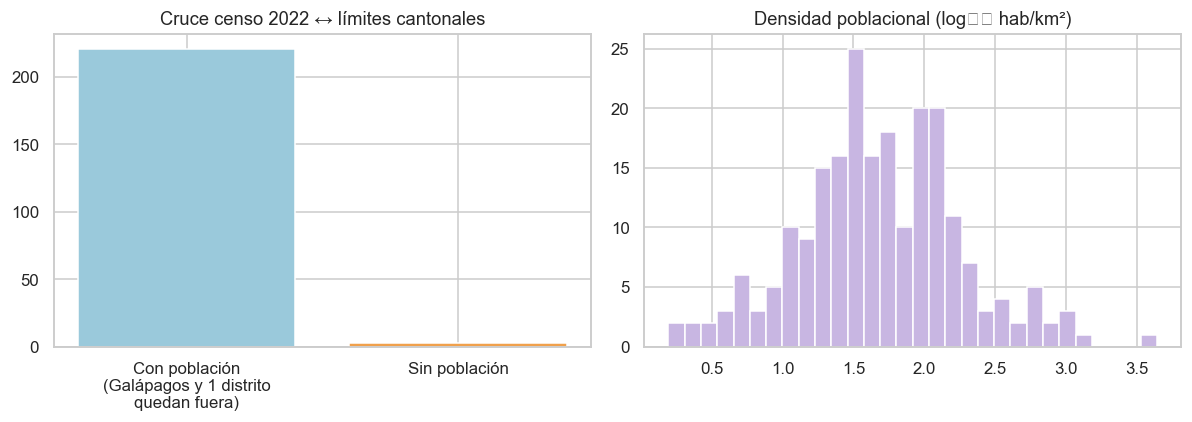

In [13]:
# --- Figura: calidad del cruce población ↔ geometría ---
fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
con_pob = base["poblacion_2022"] > 0
ejes[0].bar(["Con población\n(Galápagos y 1 distrito\nquedan fuera)", "Sin población"],
            [con_pob.sum(), (~con_pob).sum()], color=["#9AC9DB", "#F0A04B"])
ejes[0].set_title("Cruce censo 2022 ↔ límites cantonales")
ejes[1].hist(np.log10(base.loc[con_pob, "densidad_hab_km2"] + 1), bins=30, color="#C8B6E2")
ejes[1].set_title("Densidad poblacional (log₁₀ hab/km²)")
plt.tight_layout()
plt.savefig(FIG / "03_cruce_poblacion.png", bbox_inches="tight")
plt.show()

In [14]:
print("Cantones sin población asignada:", sorted(base.loc[~con_pob, "canton"].tolist()))

Cantones sin población asignada: ['El Piedrero', 'Las Golondrinas', 'Manga del Cura']


## Resumen de la fase 3

| Entrada | Registros | Salida | Registros |
|---|---|---|---|
| Catálogo crudo M≥4 | 2.589 sismos | Catálogo limpio | 2.589 |
| Sismos con cantón | — | Asignados | 2.130 (1.142 dentro + 988 por proximidad ≤150 km) |
| Límites cantonales | 224 polígonos | Dataset cantonal | 224 filas |
| Censo 2022 (tabulado 1.1) | 221 cantones | Con población | 221/224 |

**Limitaciones documentadas:**
- Dos pares de cantones homónimos (Bolívar y Olmedo, en provincias distintas)
  comparten clave de nombre; se les asigna la misma fila de resumen sísmico.
- Los eventos a >150 km de cualquier cantón (océano abierto) no se asignan.
- La población es la del Censo 2022; la exposición real varía con la hora del
  día (escuelas, lugares de trabajo) y no se modela aquí.